In [19]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from pathlib import Path

In [20]:
SCRIPT_DIR = Path.cwd()
RESULTS_DIR = SCRIPT_DIR.parent/"results"

In [25]:
ds = [9, 13]

In [27]:
df = pd.concat(
    [pd.read_csv(RESULTS_DIR / f"summary_d{d}_chi6_bit-flip.csv").assign(d=d) for d in ds],
    ignore_index=True
)
df_sorted = df.sort_values(by = ["d", "noise"])

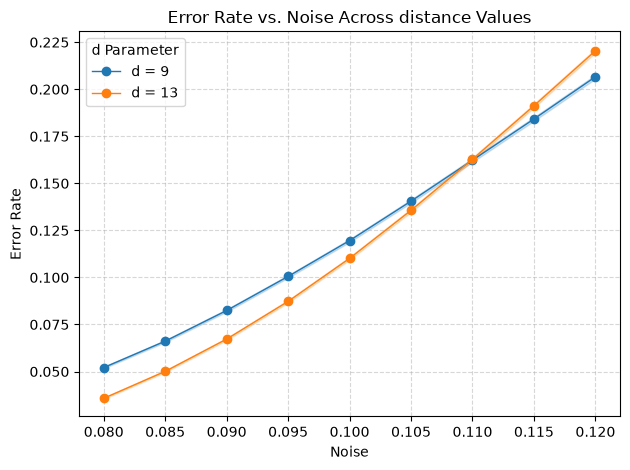

In [28]:
for d_val, sub_df in df_sorted.groupby("d"):
    line, = plt.plot(
        sub_df["noise"], 
        sub_df["error_rate"], 
        marker="o", 
        linewidth=1, 
        label=f"d = {d_val}"
    )
    plt.fill_between(
        sub_df["noise"],
        sub_df["ci_low"],
        sub_df["ci_high"],
        color=line.get_color(),
        alpha=0.2  # Transparency for confidence region
    )

plt.xlabel("Noise")
plt.ylabel("Error Rate")
plt.title("Error Rate vs. Noise Across distance Values")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="d Parameter")
plt.tight_layout()
plt.show()

In [29]:
from src.generate_surface_code import *

In [30]:
code = SurfaceCode(3, "depolarize", 0.1635)

In [31]:
code.dem

stim.DetectorErrorModel('''
    error(0.109) D0 D1
    error(0.109) D0 D2
    error(0.109) D0 L0
    error(0.109) D1
    error(0.109) D1 D3
    error(0.109) D2 D3
    error(0.109) D2 D4
    error(0.109) D2 L0
    error(0.109) D3
    error(0.109) D3 D5
    error(0.109) D4 D5
    error(0.109) D4 L0
    error(0.109) D5
    detector(0, 1, 0) D0
    detector(0, 3, 0) D1
    detector(2, 1, 0) D2
    detector(2, 3, 0) D3
    detector(4, 1, 0) D4
    detector(4, 3, 0) D5
    detector(0, 1, 1) D6
    detector(0, 3, 1) D7
    detector(2, 1, 1) D8
    detector(2, 3, 1) D9
    detector(4, 1, 1) D10
    detector(4, 3, 1) D11
''')